# State-dependent transmission done right

**Does the same shock hit harder when the economy is already in a bad
state?** Regime models — threshold VARs, Markov-switching VARs, threshold
VECMs — exist to answer exactly that. But fitting one and then pushing its
per-regime coefficients through a *linear* IRF routine quietly answers a
different question: "what if the economy were locked in that regime
forever?" For a long time that frozen-regime shortcut was the only impulse
response the regime fits in this package could offer. This notebook builds
the correct object — the **generalized IRF** of Koop, Pesaran and Potter
(1996, *J. Econometrics*) — and uses it to recover a planted asymmetry,
test it with a bootstrap band, and expose size/sign nonlinearity in the
style of Kilian and Vigfusson (2011).

## From linear IRF to generalized IRF in math

A two-regime threshold VAR switches its dynamics on a lagged threshold
variable $z_{t-d}$:
$$ y_t = c^{(r_t)} + A^{(r_t)} y_{t-1} + \varepsilon_t^{(r_t)}, \qquad
   r_t = \mathbb{1}\{z_{t-d} > c\}. $$
In a linear VAR the IRF is one deterministic path. Here the response
depends on the **history** $\omega_{t-1}$ (which regime you start in) and
on the shock's **size and sign** (a big shock can push $z$ across the
threshold mid-flight), so KPP define the IRF as a conditional expectation
and integrate the future out by Monte Carlo:
$$ GI(h, \delta, \omega_{t-1}) =
   \mathbb{E}\!\left[y_{t+h} \mid \varepsilon_{j,t}+\delta,\ \omega_{t-1}\right]
 - \mathbb{E}\!\left[y_{t+h} \mid \omega_{t-1}\right]. $$
The estimator simulates **paired paths**: a baseline with innovations
$\varepsilon \sim N(0, I)$ mapped through the *current regime's* Cholesky
factor, and a shocked twin that adds $\delta$ to identified shock $j$ at
$h=0$ — same draws otherwise. Along both paths the regime is re-evaluated
from the simulated $z$ at every step: **switching is endogenous**. Averaging
over histories drawn from the sample, conditional on the starting regime,
gives $GI_{\text{calm}}(h)$, $GI_{\text{stress}}(h)$, and the
transmission-asymmetry statistic
$$ \Delta(h) = GI_{\text{stress}}(h) - GI_{\text{calm}}(h), $$
banded by bootstrapping over the drawn histories. Kilian-Vigfusson's check
completes the toolkit: in a linear model $GI(2\delta) = 2\,GI(\delta)$ and
$GI(-\delta) = -GI(\delta)$, so plotting $GI(\delta)/\delta$ across sizes
and signs measures how nonlinear the transmission really is.

**Intuition.** A linear IRF is a single number per horizon because a linear
model treats every quarter and every shock size identically. A regime model
does not: transmission depends on where the economy *is* — and, crucially,
on where the shock *sends* it. If a financial-stress shock drags the
economy across the threshold, the shock changes the very dynamics it will
propagate through; freezing the regime assumes away precisely that
feedback. The GIRF keeps it: histories come from the sample (so "starting
in stress" means the stress quarters the data actually contains), paths
switch regimes endogenously, and the IRF becomes an *average of futures*
rather than a mechanical recursion. The price is simulation noise; the
payoff is an object that can honestly differ across regimes, sizes, and
signs — and a difference band that tells you whether it does.

## Setup — a simulated economy with calm and stress regimes

Two variables: a financial-conditions index ($z_t$, column 0 — the
threshold variable) and output growth (column 1). We **plant** the state
dependence: in the stress regime ($z_{t-1} > 0$) the FCI is more
persistent (0.8 vs 0.5) and drags growth down five times harder (−0.5 vs
−0.1). The innovation covariance is the *identity in both regimes*, so
every asymmetry below is transmission, not impact volatility.

T = 600 quarters | share of stress quarters = 0.588


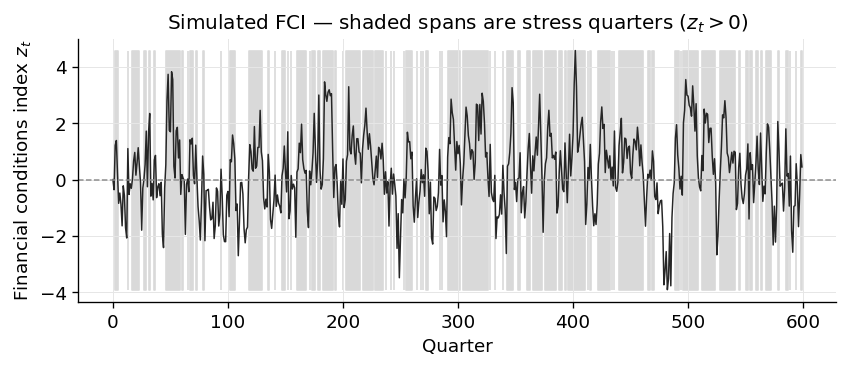

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.var.estimate import estimate_var
from puremacro.var.irf import irf as var_irf
from puremacro.var.regime import girf, tvar_fit
from puremacro.var.regime.threshold import TVARResult

A_CALM = np.array([[0.5, 0.0],      # FCI moderately persistent
                   [-0.1, 0.4]])    # ...and a mild drag on growth
A_STRESS = np.array([[0.8, 0.0],    # FCI very persistent under stress
                     [-0.5, 0.4]])  # ...and a 5x stronger drag on growth

def simulate_economy(T=600, seed=20):
    """Self-exciting TVAR(1): regime decided by last quarter's FCI."""
    rng = np.random.default_rng(seed)
    Y = np.zeros((T, 2))
    for t in range(1, T):
        A = A_STRESS if Y[t - 1, 0] > 0.0 else A_CALM
        Y[t] = A @ Y[t - 1] + rng.standard_normal(2)
    return Y

Y = simulate_economy()
stress_share = float((Y[:, 0] > 0.0).mean())
print(f"T = {len(Y)} quarters | share of stress quarters = {stress_share:.3f}")
assert 0.40 < stress_share < 0.70   # both regimes well populated

fig, ax = plt.subplots(figsize=(7.2, 3.2))
ax.plot(Y[:, 0], color="0.15", linewidth=0.9)
ax.axhline(0.0, color="0.55", linewidth=0.9, linestyle="--")
ax.fill_between(np.arange(len(Y)), Y[:, 0].min(), Y[:, 0].max(),
                where=Y[:, 0] > 0.0, color="0.85", zorder=0)
ax.set_xlabel("Quarter")
ax.set_ylabel("Financial conditions index $z_t$")
ax.set_title("Simulated FCI — shaded spans are stress quarters ($z_t > 0$)")
plt.tight_layout()
plt.show()

## Fit the threshold VAR

`tvar_fit` grid-searches the threshold $c$ and delay $d$ (Tsay 1998) and
runs OLS per regime. Nothing tells it the true split is at zero with
$d=1$ — it has to find that, and the planted coefficient gap, on its own.

In [2]:
fit = tvar_fit(Y, threshold_var_idx=0, p=1, delay_grid=(1, 2), n_threshold_grid=40)
print(f"threshold c = {fit.threshold:+.3f} (true 0.0) | delay d = {fit.delay} (true 1)")
print(f"regime split: {fit.n_low} calm / {fit.n_high} stress quarters")
print("A_low  (calm)  =", np.round(fit.A_low, 3).tolist())
print("A_high (stress)=", np.round(fit.A_high, 3).tolist())
assert fit.delay == 1
assert abs(fit.threshold) < 0.5                       # near the true zero
assert fit.A_high[1, 0] < fit.A_low[1, 0] - 0.25      # planted cross-effect gap

threshold c = +0.236 (true 0.0) | delay d = 1 (true 1)
regime split: 294 calm / 305 stress quarters
A_low  (calm)  = [[0.526, -0.089], [-0.11, 0.356]]
A_high (stress)= [[0.691, 0.008], [-0.472, 0.419]]


**Read the output.** The grid lands close to the truth: threshold near
zero, delay 1, and the estimated stress regime carries both planted
fingerprints — higher FCI persistence ($\approx 0.7$ vs $0.5$) and the
much stronger growth drag ($\approx -0.47$ vs $-0.11$). The attenuation of
the persistence estimate (0.7, not 0.8) is the usual price of
misclassified observations near the threshold. So far this is just
estimation; the question is what these two coefficient blocks *mean* for
a shock — and that is not answerable by feeding either block to a linear
IRF.

## The GIRF: histories, endogenous switching, paired simulation

One call runs the full KPP construction: draw 40 histories per starting
regime from the sample, simulate 80 paired paths per history with the
impulse added to the identified FCI shock at $h=0$ (Cholesky within
regime), let the regime switch endogenously along every path, and average.
`shock_size=[1, 2, -1, -2]` adds the Kilian-Vigfusson size/sign menu, and
the between-regime difference comes with a 90% bootstrap band.

Regime GIRF (tvar)
  regimes           : 2 ('low', 'high')
  shock / sizes     : eq 0 / [1.0, 2.0, -1.0, -2.0]
  horizon           : 16
  histories x sims  : 40 x 80 per regime
  difference band   : 90% bootstrap, B = 300

growth response at h=2: calm -0.238 | stress -0.418
difference (stress-calm) at h=2: -0.179, 90% band [-0.199, -0.163]
cumulative growth loss in stress: frozen-regime -2.56 vs GIRF -1.93


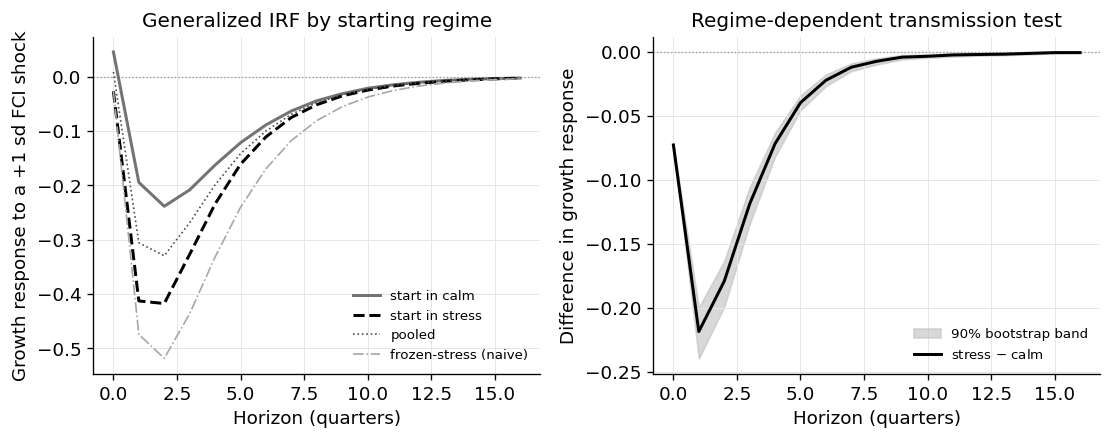

In [3]:
res = girf(fit, Y, shock=0, horizon=16, n_hist=40, n_sim=80,
           shock_size=[1.0, 2.0, -1.0, -2.0], n_boot=300, rng=16)
print(res.summary())

h = np.arange(res.horizon + 1)
g_calm = res.girf_by_regime[0, 0]     # (+1 sd shock) x (H+1, n)
g_strs = res.girf_by_regime[1, 0]
d_gr = res.difference[0, :, 1]
d_lo = res.difference_lo[0, :, 1]
d_hi = res.difference_hi[0, :, 1]
print(f"growth response at h=2: calm {g_calm[2, 1]:+.3f} | stress {g_strs[2, 1]:+.3f}")
print(f"difference (stress-calm) at h=2: {d_gr[2]:+.3f}, 90% band "
      f"[{d_lo[2]:+.3f}, {d_hi[2]:+.3f}]")
assert g_strs[2, 1] < g_calm[2, 1] - 0.10   # stress transmission is stronger...
assert d_hi[2] < -0.10                      # ...and the band excludes zero

# the naive frozen-regime IRF: pretend the economy never leaves stress
naive = var_irf([fit.A_high], np.linalg.cholesky(fit.Sigma_high), 16)[:, :, 0]
cum_naive, cum_girf = naive[:, 1].sum(), g_strs[:, 1].sum()
print(f"cumulative growth loss in stress: frozen-regime {cum_naive:+.2f} "
      f"vs GIRF {cum_girf:+.2f}")
assert cum_naive < cum_girf - 0.30          # freezing the regime overstates it

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.8))
axes[0].axhline(0, color="0.6", linewidth=0.8, linestyle=":")
axes[0].plot(h, g_calm[:, 1], color="0.45", linewidth=1.8, label="start in calm")
axes[0].plot(h, g_strs[:, 1], color="0.00", linewidth=1.8, linestyle="--",
             label="start in stress")
axes[0].plot(h, res.girf_pooled[0, :, 1], color="0.30", linewidth=1.0,
             linestyle=":", label="pooled")
axes[0].plot(h, naive[:, 1], color="0.65", linewidth=1.0, linestyle="-.",
             label="frozen-stress (naive)")
axes[0].set_xlabel("Horizon (quarters)")
axes[0].set_ylabel("Growth response to a +1 sd FCI shock")
axes[0].set_title("Generalized IRF by starting regime")
axes[0].legend(fontsize=8)
axes[1].axhline(0, color="0.6", linewidth=0.8, linestyle=":")
axes[1].fill_between(h, d_lo, d_hi, color="0.75", alpha=0.6,
                     label="90% bootstrap band")
axes[1].plot(h, d_gr, color="0.00", linewidth=1.8, label="stress $-$ calm")
axes[1].set_xlabel("Horizon (quarters)")
axes[1].set_ylabel("Difference in growth response")
axes[1].set_title("Regime-dependent transmission test")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Read the output.** Left panel: the same +1 sd financial shock costs
about **−0.42** growth at $h=2$ when it lands in stress versus **−0.24**
in calm — nearly twice the damage, purely from where it lands. The naive
frozen-stress line overstates the stress response (cumulative loss −2.6 vs
−1.9): real paths *escape* to the calm regime as the FCI mean-reverts, and
the GIRF averages over those exits while the frozen recursion forbids
them. Right panel: the stress-minus-calm difference is negative and its
90% band sits **strictly below zero** through the first two years — a
direct bootstrap test of regime-dependent transmission, which here
correctly rejects symmetry because we planted the asymmetry ourselves.
One subtlety worth savoring: the FCI's *own* response differs across
regimes far less than the coefficients (0.7 vs 0.5) suggest, because a
positive shock in calm pushes the FCI across the threshold and it then
propagates under stress dynamics anyway — endogenous switching at work.

## Size and sign asymmetry, Kilian-Vigfusson style

In a linear model $GI(\delta)/\delta$ is one curve, whatever $\delta$. In
a threshold model it is not: a +2 sd shock spends more of its life in the
stress regime than a +1 sd shock, and a −1 sd shock actively *rescues*
the economy from stress. Dividing each GIRF by its own $\delta$ makes
those deviations visible.

max size deviation |GI(2)/2 - GI(1)|  (growth): 0.045
max sign deviation |GI(-1)/-1 - GI(1)| (growth): 0.097


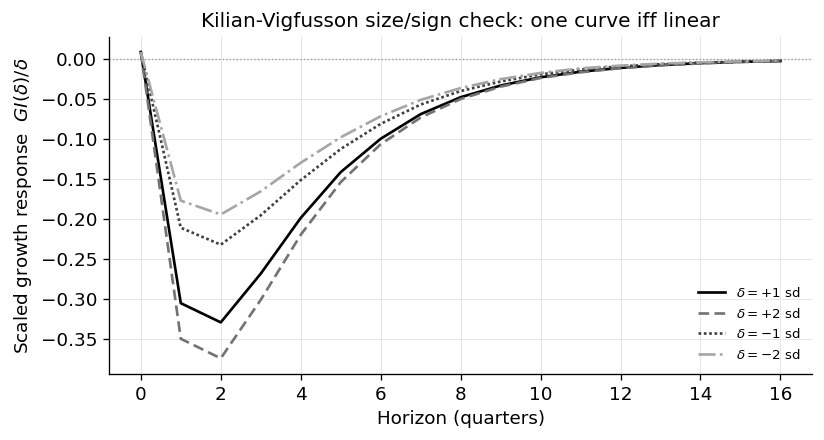

In [4]:
sc = res.scaled()                     # girf_pooled / delta, shape (S, H+1, n)
labels = [f"$\\delta = {d:+.0f}$ sd" for d in res.shock_sizes]
cols = _nbstyle.palette(4)
stys = _nbstyle.styles(4)
dev_size = np.abs(sc[1, :, 1] - sc[0, :, 1]).max()   # |GI(2d)/2 - GI(d)| gap
dev_sign = np.abs(sc[2, :, 1] - sc[0, :, 1]).max()   # |GI(-d)/(-d) - GI(d)| gap
print(f"max size deviation |GI(2)/2 - GI(1)|  (growth): {dev_size:.3f}")
print(f"max sign deviation |GI(-1)/-1 - GI(1)| (growth): {dev_sign:.3f}")
assert np.abs(sc[:, 0, :] - sc[0, 0, :]).max() < 1e-12  # impact IS proportional
assert dev_size > 0.02 and dev_sign > 0.05              # dynamics are NOT

fig, ax = plt.subplots(figsize=(7.0, 3.8))
ax.axhline(0, color="0.6", linewidth=0.8, linestyle=":")
for s in range(4):
    ax.plot(h, sc[s, :, 1], color=cols[s], linestyle=stys[s], linewidth=1.6,
            label=labels[s])
ax.set_xlabel("Horizon (quarters)")
ax.set_ylabel("Scaled growth response  $GI(\\delta)/\\delta$")
ax.set_title("Kilian-Vigfusson size/sign check: one curve iff linear")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Read the output.** At $h=0$ all four curves coincide *exactly* — the
impact response is $\mathrm{chol}(\Sigma_r)e_j\delta$, proportional by
construction — so any spread at $h \geq 1$ is pure transmission
nonlinearity. And it spreads: positive shocks (which recruit the stress
regime) transmit more damage per sd than negative ones (which flee it),
and $\pm 2$ sd shocks deviate more than $\pm 1$ sd, because larger
impulses relocate more paths across the threshold. If someone hands you
one IRF for a regime model with no $\delta$ on the label, this plot is
the question to ask.

## The linear-limit sanity check — validation you can rerun

How do we know the simulator is right? Force the model to be linear and
demand the closed form back. Build a `TVARResult` whose two regimes are
*identical copies* of a fitted linear VAR: the threshold still "switches"
regimes along every path, but both regimes carry the same coefficients,
so the GIRF must collapse to `var.irf` — and because the impulse is
*added* under common random numbers, the paired difference is
deterministic and the match is to machine precision, not up to Monte
Carlo noise. This is the same oracle the test suite pins.

max |GIRF - linear IRF| in the linear limit: 2.78e-16
max |regime difference| in the linear limit: 1.11e-16


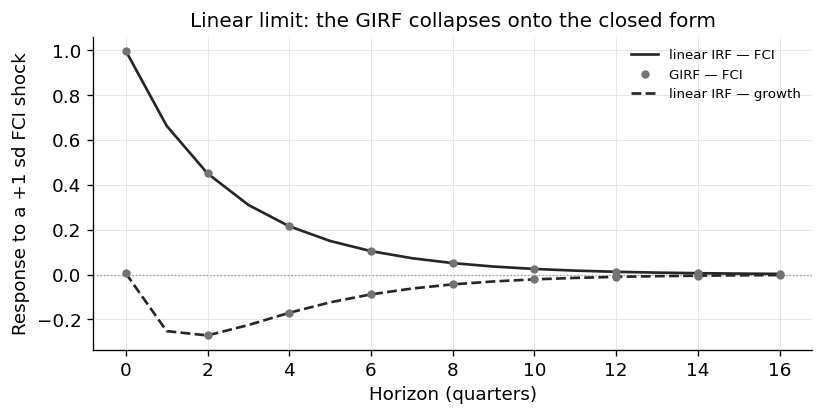

In [5]:
est = estimate_var(Y, 1)
A_hat = np.hstack(est.A_list)
fit_lin = TVARResult(
    A_low=A_hat, intercept_low=est.c, Sigma_low=est.Sigma,
    A_high=A_hat.copy(), intercept_high=est.c.copy(), Sigma_high=est.Sigma.copy(),
    threshold=float(np.median(Y[:, 0])), delay=1, threshold_var_idx=0,
    n_low=0, n_high=0, rss_total=0.0, grid={},
)
chk = girf(fit_lin, Y, shock=0, horizon=16, n_hist=20, n_sim=30, n_boot=100, rng=1)
closed_form = var_irf(est.A_list, np.linalg.cholesky(est.Sigma), 16)[:, :, 0]
gap = np.abs(chk.girf_pooled[0] - closed_form).max()
print(f"max |GIRF - linear IRF| in the linear limit: {gap:.2e}")
print(f"max |regime difference| in the linear limit: {np.abs(chk.difference).max():.2e}")
assert gap < 1e-10
assert np.abs(chk.difference).max() < 1e-12

fig, ax = plt.subplots(figsize=(7.0, 3.6))
ax.axhline(0, color="0.6", linewidth=0.8, linestyle=":")
for j, (name, sty) in enumerate([("FCI", "-"), ("growth", "--")]):
    ax.plot(h, closed_form[:, j], color="0.15", linestyle=sty, linewidth=1.6,
            label=f"linear IRF — {name}")
    ax.plot(h[::2], chk.girf_pooled[0, ::2, j], "o", color="0.45", markersize=4,
            label=f"GIRF — {name}" if j == 0 else None)
ax.set_xlabel("Horizon (quarters)")
ax.set_ylabel("Response to a +1 sd FCI shock")
ax.set_title("Linear limit: the GIRF collapses onto the closed form")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**The validation moment.** This is the discipline the notebook wants you
to steal: every simulation-based estimator should ship with a limit in
which its answer is known *exactly*. For the KPP GIRF that limit is
"regimes that do not differ", and the machine-precision agreement above
(about $10^{-16}$, not $10^{-2}$) is only possible because the impulse is
added to the identified shock under common random numbers — a design
choice made *for* testability. When the linear limit holds and the
planted asymmetry is recovered with the right sign, the interesting
output (the difference band) inherits that credibility.

## Your turn — how big a shock breaks proportionality?

The fill-in below recomputes the GIRF for a shock size of your choosing
and compares it, per sd, against the +1 sd benchmark. The impact
comparison must agree *exactly* for any $\delta$ (that is the Cholesky
proportionality you verified above); the interesting number is how far
the curves drift apart at business-cycle horizons.

In [6]:
DELTA_TRY = 2.0   # ← change this: shock size in sd units (try 0.5, 3.0, -2.0, 5.0)
res_try = girf(fit, Y, shock=0, horizon=16, n_hist=30, n_sim=60,
               shock_size=[1.0, DELTA_TRY], n_boot=100, rng=2)
sc_try = res_try.scaled()
drift = np.abs(sc_try[1, :, 1] - sc_try[0, :, 1])
print(f"delta = {DELTA_TRY:+.1f} sd -> max per-sd growth drift vs +1 sd: "
      f"{drift.max():.3f} at h = {int(drift.argmax())}")
# Holds for the default and ANY delta you try: impact is exactly proportional.
assert np.allclose(sc_try[1, 0], sc_try[0, 0], atol=1e-10)

delta = +2.0 sd -> max per-sd growth drift vs +1 sd: 0.046 at h = 1


**Prompts.** (1) *Basic*: set `DELTA_TRY = -2.0` and explain the sign of
the drift using the threshold: which regime do negative FCI shocks
recruit, and why does that make them *weaker* per sd? (2) *Intermediate*:
refit the model with `delay_grid=(2,)` and rerun the GIRF — does forcing
the wrong delay shrink the stress-calm difference band toward zero, and
what does that teach about misspecifying $d$? (3) *Stretch*: replace
`tvar_fit` with `ms_var_fit(Y, K=2, p=1)` and call the *same* `girf`
function. The difference band now reflects only the impact Cholesky —
explain why the shared-$A$ Markov-switching spec cannot generate
transmission asymmetry, and what the model would need for it to do so.

## Why this matters for regime-uncertainty research

The empirical regime-uncertainty literature lives on exactly this object.
Caldara, Fuentes-Albero, Gilchrist and Zakrajšek (2016, *EER*) argue that
uncertainty shocks transmit mainly when financial conditions are tight —
a claim *about* $\Delta(h)$, testable only with a construction that lets
the economy move between tight and loose states mid-response, as here.
On the structural side, this package's regime-dependent
Diamond-Mortensen-Pissarides model
(`puremacro.models.dmp_regime_dependent`, `dmp_irf(..., regime="H")` vs
`regime="L"`) produces the same phenomenon from theory — volatility
regimes changing the surplus calculus of job creation — and the GIRF is
the reduced-form lens you would point at data generated by such a model.
The honest workflow the two share: state the regime model, simulate it
forward *with switching intact*, and report the regime difference with a
band, never a frozen-regime IRF.

**How comprehensive is this?** `girf` dispatches on all three regime fits
in `puremacro.var.regime` — `tvar_fit` (used here), `tvecm_fit`
(threshold cointegration, responses in levels), and `ms_var_fit` (regime
paths drawn from the fitted transition matrix). Single-equation
alternatives live in `puremacro.lp` (`lp_state_dep` for
Auerbach-Gorodnichenko-style state-dependent local projections);
`puremacro.uncertainty.regimes` dates the regimes themselves
(Bai-Perron breaks, calendar regimes); and notebook 06 covers the
identification conventions the Cholesky-within-regime choice inherits.